In [1]:
import pandas as pd
import os

In [75]:
"""
I have a directory "results/adam" with with csv files related to train and validation history.
train csv has columns:
- train_batch, acc, loss
and validation csv has columns:
- batch_num,val_acc,val_loss

I have 4 methods on which I did the experiments:
- anti, curriculum, curriculum_mixed, vanilla
Each method has been ran a total of 3 times.
the csv files are named as follows:
- adam_{method}_run_{run_number}_{train/val}_history.csv

for each method and for val/train, I want to create a dataframe that contains the average statistics and std
"""
methods = ['anti', 'curriculum', 'curriculum_mixed', 'vanilla']
optimizers = ['adam', 'sgd']

# load train history
def load_train_history_adam(method):
    # create empty df with columns train_batch, acc, loss
    overall_train_df = pd.DataFrame()
    for run in range(1, 4):
        file_path = f'results/adam/adam_{method}_adam_run_{run}_train_history.csv'
        df = pd.read_csv(file_path)
        # remove column std_acc
        if 'std_acc' in df.columns:
            df.drop(columns=['train_batch', 'std_acc'], inplace=True)
        # add df columns to overall_train_df with name suffix _run_{run}
        df.columns = [f"{col}_run_{run}" if col != 'train_batch' else col for col in df.columns]
        overall_train_df = pd.concat([overall_train_df, df], axis=1)

    # calculate mean and std for acc and loss for each index
    overall_train_df['acc_mean'] = overall_train_df.filter(like='acc_run_').mean(axis=1)
    overall_train_df['acc_std'] = overall_train_df.filter(like='acc_run_').std(axis=1)
    overall_train_df['loss_mean'] = overall_train_df.filter(like='loss_run_').mean(axis=1)
    overall_train_df['loss_std'] = overall_train_df.filter(like='loss_run_').std(axis=1)

    # do a rolling mean and std of size 50 for acc and loss
    overall_train_df['acc_mean'] = overall_train_df['acc_mean'].rolling(window=50).mean()
    overall_train_df['acc_std'] = overall_train_df['acc_std'].rolling(window=50).mean()
    overall_train_df['loss_mean'] = overall_train_df['loss_mean'].rolling(window=50).mean()
    overall_train_df['loss_std'] = overall_train_df['loss_std'].rolling(window=50).mean()


    return overall_train_df[['acc_mean', 'acc_std', 'loss_mean', 'loss_std']]

def load_train_history_sgd(method):
    # create empty df with columns train_batch, acc, loss
    if method == "vanilla":
        return pd.DataFrame()  # No data for vanilla method with SGD
    overall_train_df = pd.DataFrame()
    for run in range(2, 4):
        file_path = f'results/sgd/esc50_cnn_{method}_sgd_run_{run}_train_history.csv'
        df = pd.read_csv(file_path)
        # remove column std_acc
        if 'std_acc' in df.columns:
            df.drop(columns=['train_batch', 'std_acc'], inplace=True)
        # add df columns to overall_train_df with name suffix _run_{run}
        df.columns = [f"{col}_run_{run}" if col != 'train_batch' else col for col in df.columns]
        overall_train_df = pd.concat([overall_train_df, df], axis=1)

    # calculate mean and std for acc and loss for each index
    overall_train_df['acc_mean'] = overall_train_df.filter(like='acc_run_').mean(axis=1)
    overall_train_df['acc_std'] = overall_train_df.filter(like='acc_run_').std(axis=1)
    overall_train_df['loss_mean'] = overall_train_df.filter(like='loss_run_').mean(axis=1)
    overall_train_df['loss_std'] = overall_train_df.filter(like='loss_run_').std(axis=1)

    # do a rolling mean and std of size 50 for acc and loss
    overall_train_df['acc_mean'] = overall_train_df['acc_mean'].rolling(window=50).mean()
    overall_train_df['acc_std'] = overall_train_df['acc_std'].rolling(window=50).mean()
    overall_train_df['loss_mean'] = overall_train_df['loss_mean'].rolling(window=50).mean()
    overall_train_df['loss_std'] = overall_train_df['loss_std'].rolling(window=50).mean()

    return overall_train_df[['acc_mean', 'acc_std', 'loss_mean', 'loss_std']]


# now create a function that does the same but for validation history
def load_val_history_adam(method):
    overall_val_df = pd.DataFrame()
    for run in range(1, 4):
        file_path = f'results/adam/adam_{method}_adam_run_{run}_val_history.csv'
        df = pd.read_csv(file_path)
        # remove column std_acc
        if 'std_acc' in df.columns:
            df.drop(columns=['batch_num', 'std_acc'], inplace=True)
        # add df columns to overall_val_df with name suffix _run_{run}
        df.columns = [f"{col}_run_{run}" if col != 'batch_num' else col for col in df.columns]
        overall_val_df = pd.concat([overall_val_df, df], axis=1)

    # calculate mean and std for val_acc and val_loss for each index
    overall_val_df['val_acc_mean'] = overall_val_df.filter(like='val_acc_run_').mean(axis=1)
    overall_val_df['val_acc_std'] = overall_val_df.filter(like='val_acc_run_').std(axis=1)
    overall_val_df['val_loss_mean'] = overall_val_df.filter(like='val_loss_run_').mean(axis=1)
    overall_val_df['val_loss_std'] = overall_val_df.filter(like='val_loss_run_').std(axis=1)

    # # do a rolling mean and std of size 50 for val_acc and val_loss
    # overall_val_df['val_acc_mean'] = overall_val_df['val_acc_mean'].rolling(window=50).mean()
    # overall_val_df['val_acc_std'] = overall_val_df['val_acc_std'].rolling(window=50).mean()
    # overall_val_df['val_loss_mean'] = overall_val_df['val_loss_mean'].rolling(window=50).mean()
    # overall_val_df['val_loss_std'] = overall_val_df['val_loss_std'].rolling(window=50).mean()

    return overall_val_df[['val_acc_mean', 'val_acc_std', 'val_loss_mean', 'val_loss_std']]

def load_val_history_sgd(method):
    if method == "vanilla":
        return pd.DataFrame()  # No data for vanilla method with SGD
    overall_val_df = pd.DataFrame()
    for run in range(2, 4):
        file_path = f'results/sgd/esc50_cnn_{method}_sgd_run_{run}_val_history.csv'
        df = pd.read_csv(file_path)
        # remove column std_acc
        if 'std_acc' in df.columns:
            df.drop(columns=['batch_num', 'std_acc'], inplace=True)
        # add df columns to overall_val_df with name suffix _run_{run}
        df.columns = [f"{col}_run_{run}" if col != 'batch_num' else col for col in df.columns]
        overall_val_df = pd.concat([overall_val_df, df], axis=1)

    # calculate mean and std for val_acc and val_loss for each index
    overall_val_df['val_acc_mean'] = overall_val_df.filter(like='val_acc_run_').mean(axis=1)
    overall_val_df['val_acc_std'] = overall_val_df.filter(like='val_acc_run_').std(axis=1)
    overall_val_df['val_loss_mean'] = overall_val_df.filter(like='val_loss_run_').mean(axis=1)
    overall_val_df['val_loss_std'] = overall_val_df.filter(like='val_loss_run_').std(axis=1)

    # # do a rolling mean and std of size 50 for val_acc and val_loss
    # overall_val_df['val_acc_mean'] = overall_val_df['val_acc_mean'].rolling(window=50).mean()
    # overall_val_df['val_acc_std'] = overall_val_df['val_acc_std'].rolling(window=50).mean()
    # overall_val_df['val_loss_mean'] = overall_val_df['val_loss_mean'].rolling(window=50).mean()
    # overall_val_df['val_loss_std'] = overall_val_df['val_loss_std'].rolling(window=50).mean()

    return overall_val_df[['val_acc_mean', 'val_acc_std', 'val_loss_mean', 'val_loss_std']]

In [ ]:
for method in methods:
    X = load_train_history_adam(method)
    X.to_csv(f'results/final_results/adam_{method}_train_history.csv', index=True)
    X = load_train_history_sgd(method)
    X.to_csv(f'results/final_results/sgd_{method}_train_history.csv', index=True)

In [65]:
# load all the train history dataframes
train_dfs = {}
for method in methods:
    train_dfs[method] = {
        'adam': load_train_history_adam(method),
        'sgd': load_train_history_sgd(method)
    }

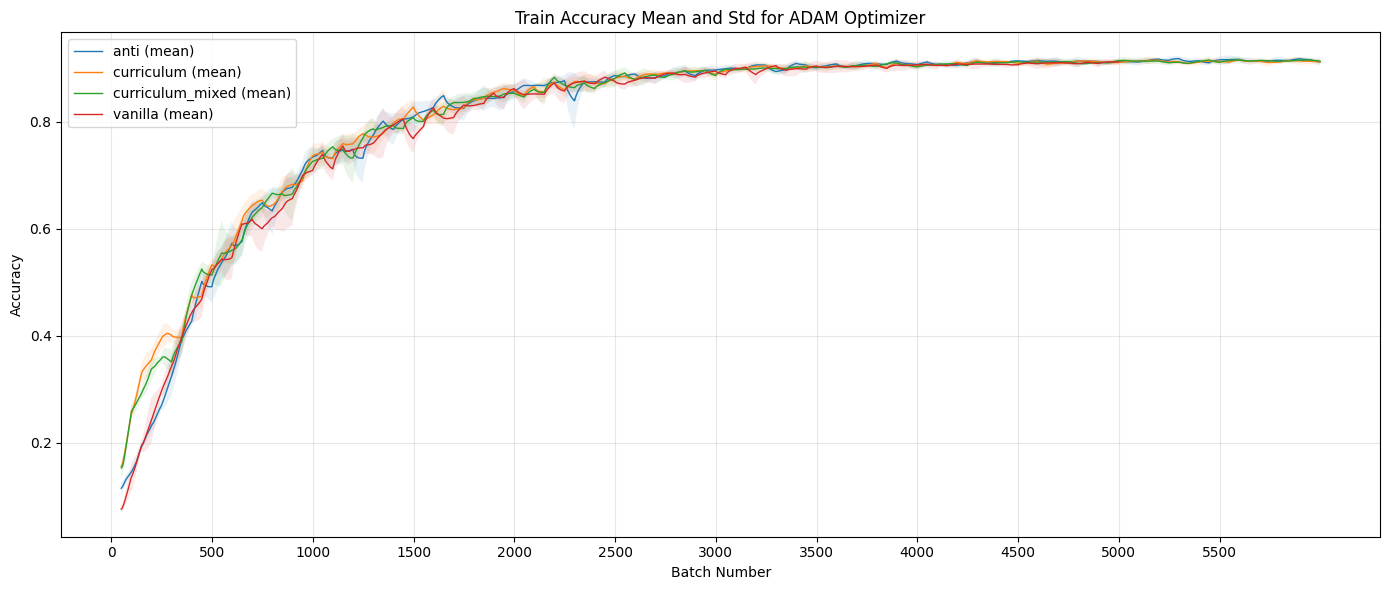

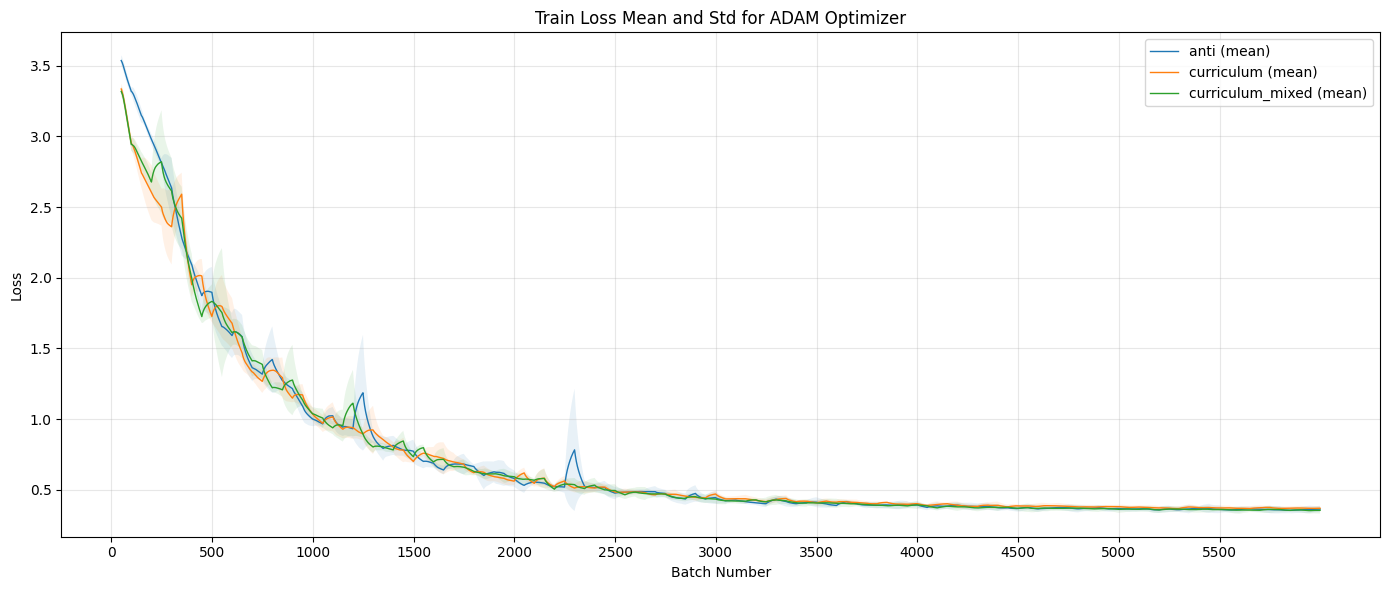

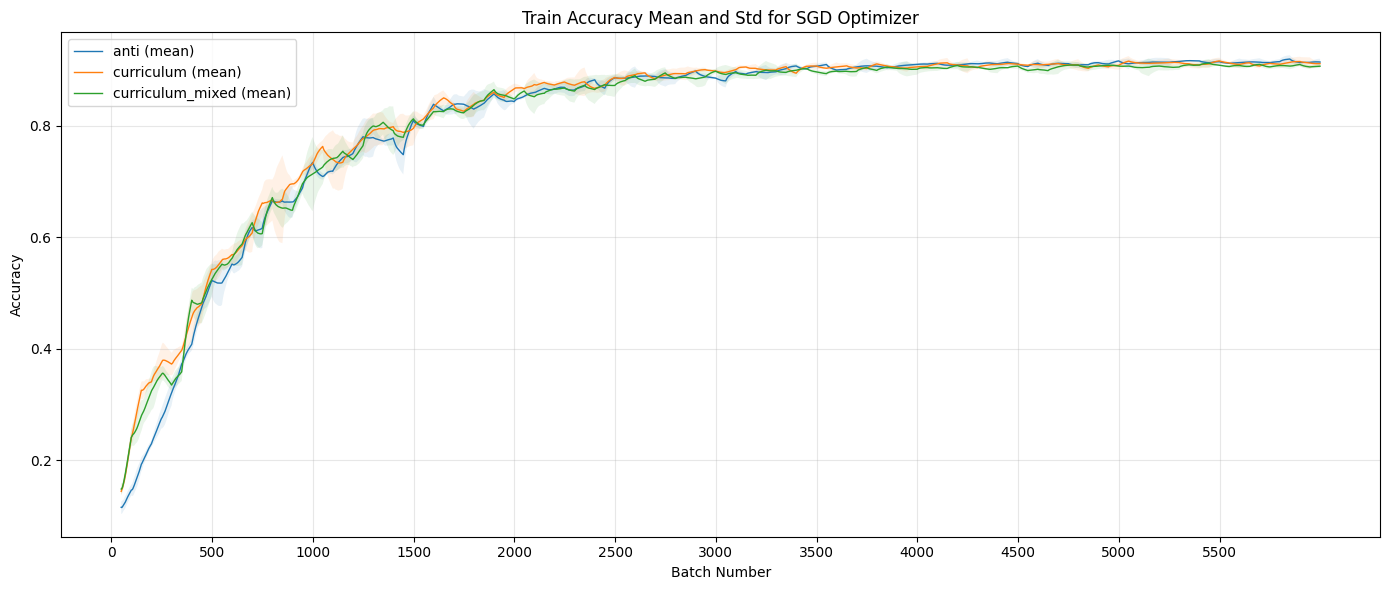

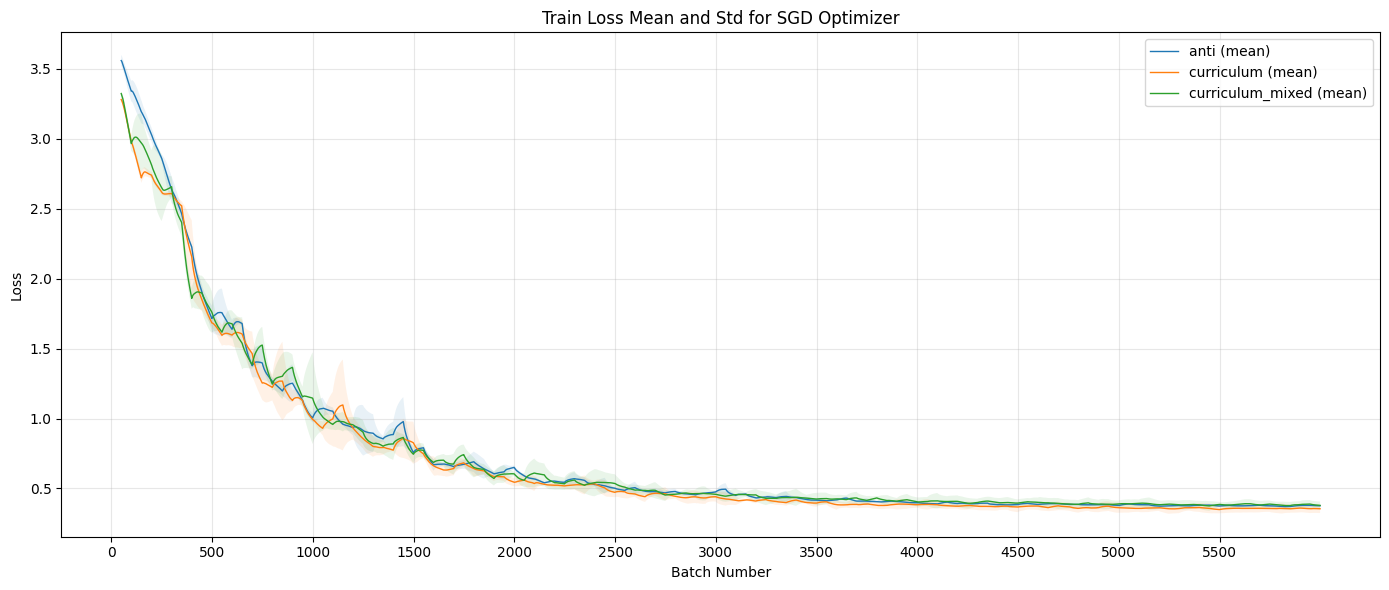

In [68]:
# do a line plot of the train loss mean with a hue for the std
import matplotlib.pyplot as plt
def plot_train_metrics(train_dfs, optimizer):
    # Plot for accuracy
    plt.figure(figsize=(14, 6))
    for method in methods:
        df = train_dfs[method][optimizer]
        if not df.empty:
            plt.plot(df.index, df['acc_mean'], label=f"{method} (mean)", linewidth=1.0)
            plt.fill_between(df.index, 
                            df['acc_mean'] - df['acc_std'], 
                            df['acc_mean'] + df['acc_std'], 
                            alpha=0.1)

    plt.title(f'Train Accuracy Mean and Std for {optimizer.upper()} Optimizer')
    plt.xlabel('Batch Number')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    # Only show every 500th tick to avoid overcrowding
    if not all(df.empty for method in methods for df in [train_dfs[method][optimizer]]):
        plt.xticks([i for i in range(0, max([len(train_dfs[m][optimizer].index) for m in methods if not train_dfs[m][optimizer].empty]), 500)])
    plt.tight_layout()
    plt.savefig(f'results/final_results/{optimizer}_train_acc_plot.png', dpi=300)
    plt.show()
    
    # Plot for loss
    plt.figure(figsize=(14, 6))
    for method in methods:
        if method == "vanilla":
            continue
        df = train_dfs[method][optimizer]
        if not df.empty:
            plt.plot(df.index, df['loss_mean'], label=f"{method} (mean)", linewidth=1.0)
            plt.fill_between(df.index, 
                            df['loss_mean'] - df['loss_std'], 
                            df['loss_mean'] + df['loss_std'], 
                            alpha=0.1)

    plt.title(f'Train Loss Mean and Std for {optimizer.upper()} Optimizer')
    plt.xlabel('Batch Number')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    # Only show every 500th tick to avoid overcrowding
    if not all(df.empty for method in methods for df in [train_dfs[method][optimizer]]):
        plt.xticks([i for i in range(0, max([len(train_dfs[m][optimizer].index) for m in methods if not train_dfs[m][optimizer].empty]), 500)])
    plt.tight_layout()
    plt.savefig(f'results/final_results/{optimizer}_train_loss_plot.png', dpi=300)
    plt.show()

# Generate plots for both optimizers
plot_train_metrics(train_dfs, 'adam')
plot_train_metrics(train_dfs, 'sgd')

In [76]:
for method in methods:
    X = load_val_history_adam(method)
    X.to_csv(f'results/final_results/adam_{method}_val_history.csv', index=True)
    X = load_val_history_sgd(method)
    X.to_csv(f'results/final_results/sgd_{method}_val_history.csv', index=True)

In [77]:
# load validation history
val_dfs = {}
for method in methods:
    val_dfs[method] = {
        'adam': load_val_history_adam(method),
        'sgd': load_val_history_sgd(method)
    }

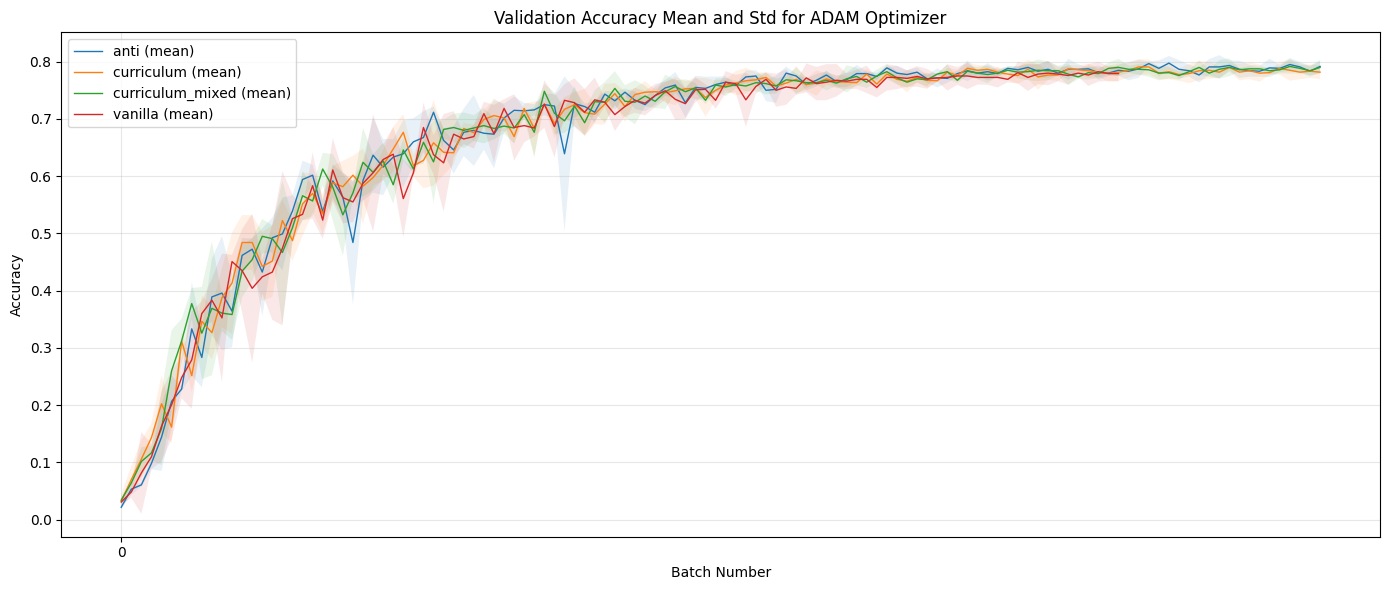

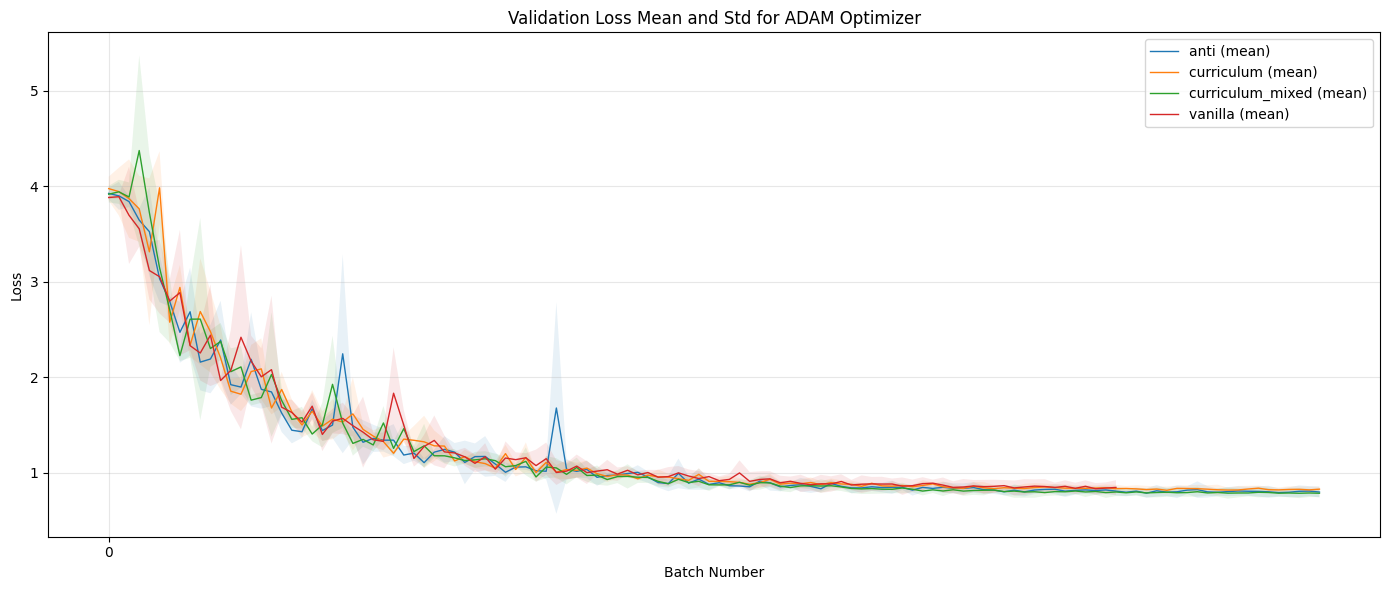

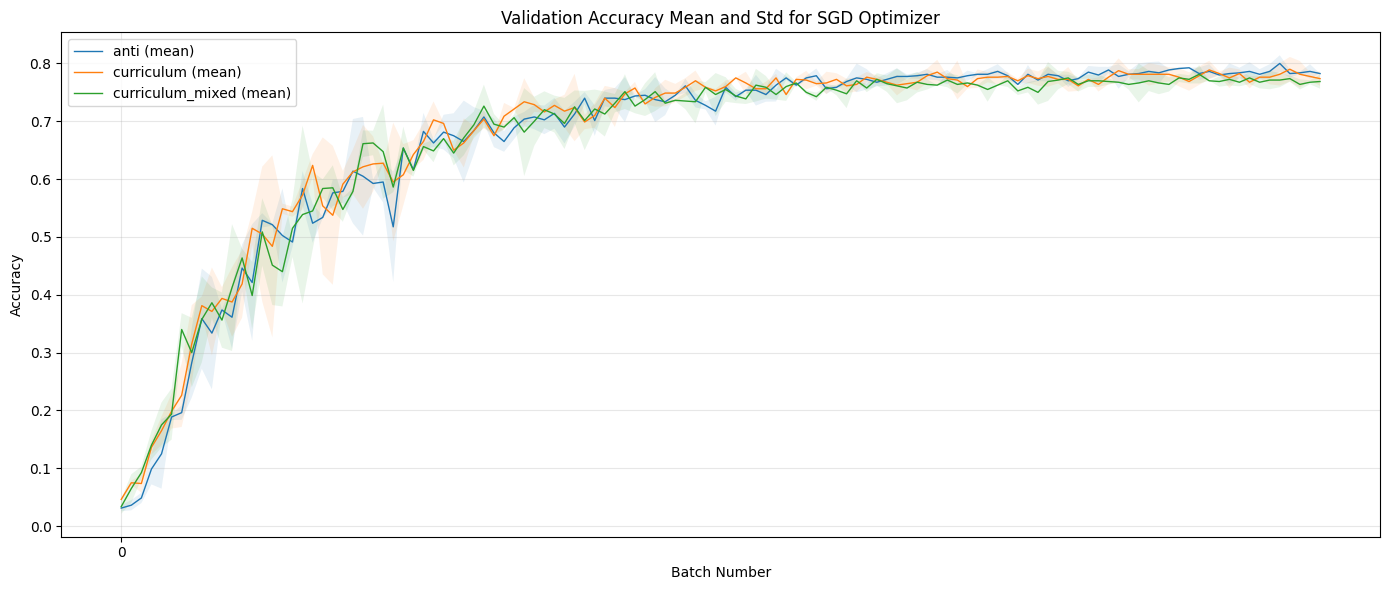

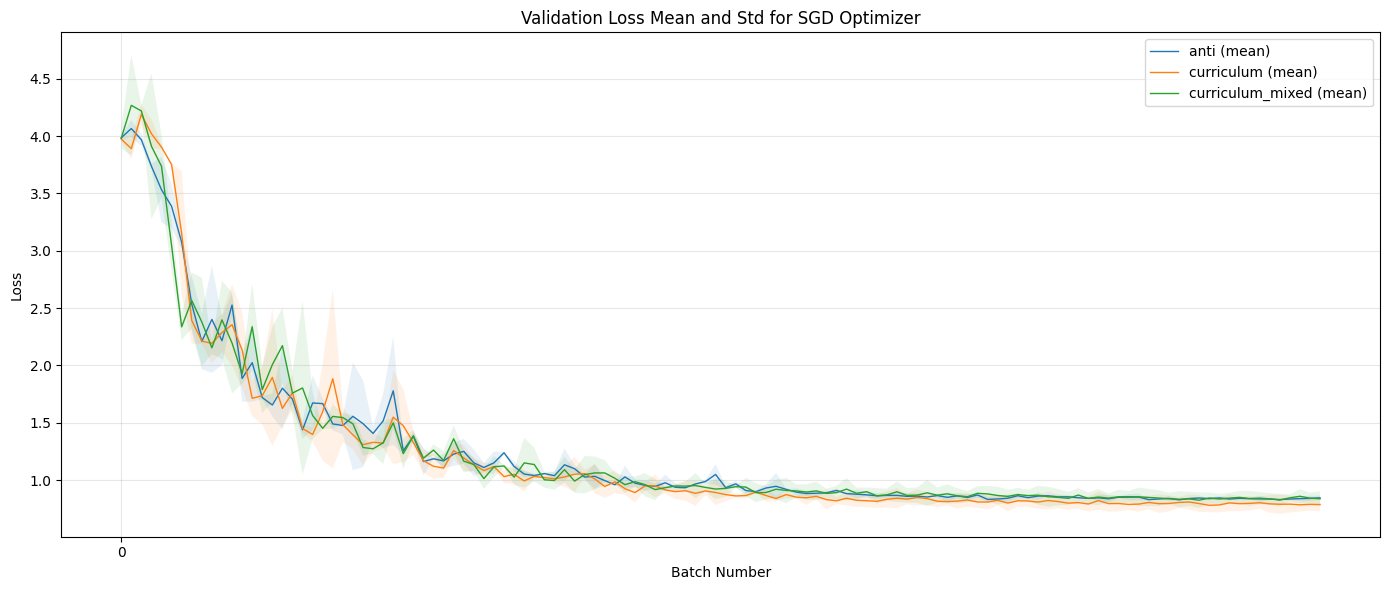

In [78]:
# do a line plot of the val loss mean with a hue for the std
def plot_val_metrics(val_dfs, optimizer):
    # Plot for validation accuracy
    plt.figure(figsize=(14, 6))
    for method in methods:
        df = val_dfs[method][optimizer]
        if not df.empty:
            plt.plot(df.index, df['val_acc_mean'], label=f"{method} (mean)", linewidth=1.0)
            plt.fill_between(df.index, 
                            df['val_acc_mean'] - df['val_acc_std'], 
                            df['val_acc_mean'] + df['val_acc_std'], 
                            alpha=0.1)

    plt.title(f'Validation Accuracy Mean and Std for {optimizer.upper()} Optimizer')
    plt.xlabel('Batch Number')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    # Only show every 500th tick to avoid overcrowding
    if not all(df.empty for method in methods for df in [val_dfs[method][optimizer]]):
        plt.xticks([i for i in range(0, max([len(val_dfs[m][optimizer].index) for m in methods if not val_dfs[m][optimizer].empty]), 500)])
    plt.tight_layout()
    plt.savefig(f'results/final_results/{optimizer}_val_acc_plot.png', dpi=300)
    plt.show()
    
    # Plot for validation loss
    plt.figure(figsize=(14, 6))
    for method in methods:
        if method == "vanilla" and optimizer == 'sgd':
            continue
        df = val_dfs[method][optimizer]
        if not df.empty:
            plt.plot(df.index, df['val_loss_mean'], label=f"{method} (mean)", linewidth=1.0)
            plt.fill_between(df.index, 
                            df['val_loss_mean'] - df['val_loss_std'], 
                            df['val_loss_mean'] + df['val_loss_std'], 
                            alpha=0.1)

    plt.title(f'Validation Loss Mean and Std for {optimizer.upper()} Optimizer')
    plt.xlabel('Batch Number')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    # Only show every 500th tick to avoid overcrowding
    if not all(df.empty for method in methods for df in [val_dfs[method][optimizer]]):
        plt.xticks([i for i in range(0, max([len(val_dfs[m][optimizer].index) for m in methods if not val_dfs[m][optimizer].empty]), 500)])
    plt.tight_layout()
    plt.savefig(f'results/final_results/{optimizer}_val_loss_plot.png', dpi=300)
    plt.show()
# Generate plots for both optimizers
plot_val_metrics(val_dfs, 'adam')
plot_val_metrics(val_dfs, 'sgd')